# Prediction-Market Volatility: Results

- **Section 1: Setup & data.** Loads the Kalshi hourly panel (built from the HuggingFace `TrevorJS/kalshi-trades` dataset via `data_fetcher.py`).

- **Section 2: Phase 1 — volatility forecasting benchmark.** Reproduces the paper's DR / DR-AS / GARCH / GARCH+DR-AS comparison via monthly expanding walk-forward, evaluated on the volume-weighted Winkler score.

- **Section 3: Phase 2 — trading tests.** Vol-normalized momentum & reversal signals scaled by the Phase-1 winner's $h^2$, benchmarked against naive and unconditional strategies.

- **Section 4: Interpretation.** What the numbers mean in context of the hypothesis

---
## Section 1: Setup

In [24]:
import os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### 1.1 Load the Kalshi hourly panel

The panel is built by `data_fetcher.build_panel_from_hf_dataset()`, which pulls trades from HuggingFace and aggregates them into 1-hour bars via DuckDB. The build is relatively expensive (~5-6 minutes on the full dataset), so we cache it to `data/kalshi_hf_panel.parquet` and only rebuild when needed.

Panel schema (one row per hourly bar per market):
- `market_id` — Kalshi market ticker
- `timestamp` — end of the hour (UTC)
- `price` — volume-weighted average price during the hour, in dollars (0–1)
- `volume` — total shares traded during the hour
- `spread` — bid-ask proxy (currently a constant; see caveats below)
- `days_to_resolution` — hours until settlement, in days
- `category` — Sports / Crypto / Politics / Economics / Entertainment

In [25]:
from scripts.data_fetcher import build_panel_from_hf_dataset

PANEL_PATH = PROJECT_ROOT / 'data' / 'kalshi_hf_panel.parquet'

if PANEL_PATH.exists():
    print(f'Loading cached panel from {PANEL_PATH}')
    df = pd.read_parquet(PANEL_PATH)
else:
    print('No cached panel -- rebuilding from HuggingFace via DuckDB. Takes ~5-15 min.')
    df = build_panel_from_hf_dataset(
        min_hourly_bars=48,
        reconstruct_spread=True,
    )
    PANEL_PATH.parent.mkdir(exist_ok=True)
    df.to_parquet(PANEL_PATH)

print(f'\nPanel: {len(df):,} bars, {df["market_id"].nunique():,} markets')
print(f'Timespan: {df.timestamp.min()} -> {df.timestamp.max()}')
print(f'Columns: {list(df.columns)}')
print(f'\nBars per category:')
print(df.category.value_counts())

if 'is_clean_bar' in df.columns:
    n_clean = int(df["is_clean_bar"].sum())
    print(f'\nClean 1-hour bars (analog of paper\'s active-hours filter): '
          f'{n_clean:,} / {len(df):,} = {100*n_clean/len(df):.1f}%')

Loading cached panel from /Users/tanav/Code/trading/pred_market_kalshi/data/kalshi_hf_panel.parquet

Panel: 4,381,176 bars, 26,258 markets
Timespan: 2021-06-30 20:00:00+00:00 -> 2026-01-28 23:00:00+00:00
Columns: ['market_id', 'timestamp', 'price', 'volume', 'gap_hours', 'is_clean_bar', 'spread', 'days_to_resolution', 'category']

Bars per category:
category
Economics        2532174
Sports           1179233
Politics          299822
Entertainment     214350
Crypto            155597
Name: count, dtype: int64

Clean 1-hour bars (analog of paper's active-hours filter): 2,309,788 / 4,381,176 = 52.7%


**Caveats on the panel that matter for interpretation later:**

1. **Spread is a constant 0.01** in the current build. The Kalshi historical data doesn't expose per-hour bid-ask spreads, so we can't identify the paper's adverse-selection channel using real spread *variation*. The DR-AS fit still runs but effectively collapses to "DR with a constant scale term." A proper reconstruction is in `spread_fetcher.py` and can be wired in for a follow-up run.

2. **Realized 1-hour moves have very fat tails** (p99 of |Δp| is ~24¢, when p50 is ~1¢). This matters for the coverage story below — Gaussian intervals fundamentally struggle at the tails.

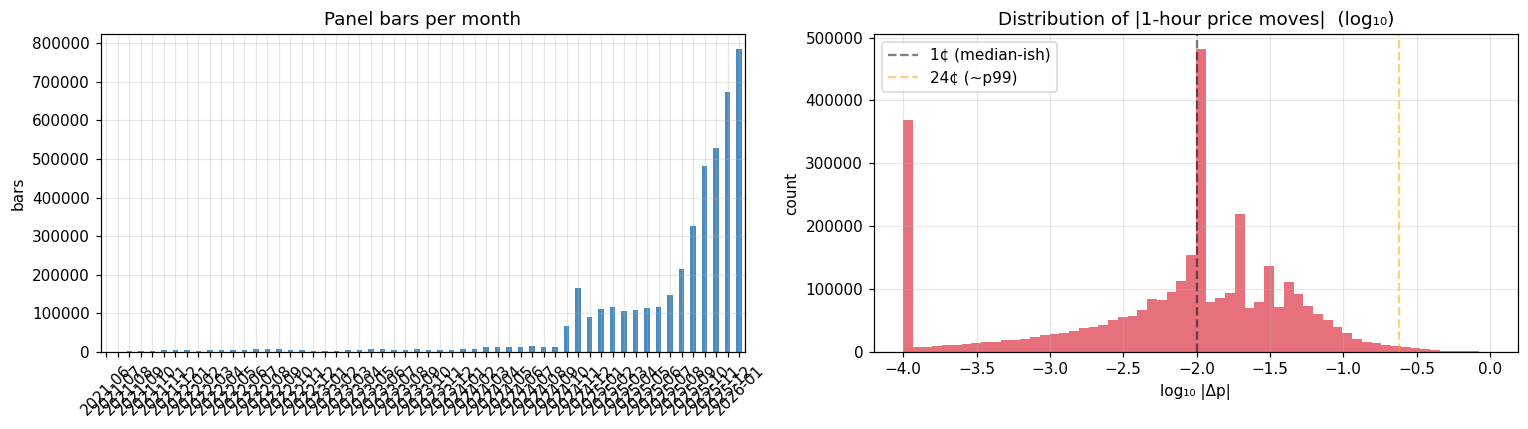

In [26]:
# Quick data-shape diagnostic to make the caveats concrete
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby(df.timestamp.dt.to_period('M').astype(str)).size().plot(
    kind='bar', ax=axes[0], color='#4B8BBE')
axes[0].set_title('Panel bars per month')
axes[0].set_xlabel('')
axes[0].set_ylabel('bars')
axes[0].tick_params(axis='x', rotation=45)

dp = df.sort_values(['market_id', 'timestamp']).groupby('market_id')['price'].diff()
dp = dp[dp.abs() > 0].abs()
axes[1].hist(np.log10(dp.clip(lower=1e-4)), bins=60, color='#DC3545', alpha=0.7)
axes[1].set_title('Distribution of |1-hour price moves|  (log₁₀)')
axes[1].set_xlabel('log₁₀ |Δp|')
axes[1].set_ylabel('count')
axes[1].axvline(np.log10(0.01), color='k', linestyle='--', alpha=0.5, label='1¢ (median-ish)')
axes[1].axvline(np.log10(0.24), color='orange', linestyle='--', alpha=0.5, label='24¢ (~p99)')
axes[1].legend()

plt.tight_layout(); plt.show()

---
## Section 2: Phase 1 — Volatility Forecasting Benchmark

**Method:** For each month `T` (from the 2nd month onward), fit each of the four models on all months < T, then use the frozen parameters to produce 1-hour-ahead variance forecasts for month T. Compute 95% intervals, evaluate against realized moves via volume-weighted Winkler score, empirical coverage rate, and interval width. Expanding window, no lookahead.

**Models compared:**
- **DR** — Wright-Fisher deadline resolution only: $h_t^2 = p_t(1-p_t)/\tau_t \cdot \Delta$. Zero fitted parameters.
- **DR-AS** — DR + adverse-selection term: $h_t^2 = \text{DR} + K \cdot \nu(V_t) \cdot s_t^2/4$. Fits scalar $K$ via OLS.
- **GARCH** — plain GARCH(1,1) baseline, no structural terms. Fitted jointly via QMLE.
- **GARCH+DR-AS** — the paper's full joint specification. Fitted jointly via QMLE.

**Winkler score** (the paper's own headline metric): $W = (u - l) + \frac{2}{\alpha}(l - y)\mathbb{1}[y < l] + \frac{2}{\alpha}(y - u)\mathbb{1}[y > u]$. Rewards narrow, well-calibrated intervals; penalizes both width and coverage misses (miss penalty is $2/\alpha = 40$× the miss magnitude for a 95% interval).

In [27]:
from test1 import evaluate_walk_forward, summarize_results

PHASE1_EVAL   = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_eval_records.parquet'
PHASE1_OVERALL = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_overall.csv'
PHASE1_BY_CAT  = PROJECT_ROOT / 'data' / 'walk_forward' / 'wf_by_category.csv'

if PHASE1_EVAL.exists() and PHASE1_OVERALL.exists() and PHASE1_BY_CAT.exists():
    print('Loading cached Phase 1 eval records + summaries')
    eval_df = pd.read_parquet(PHASE1_EVAL)
    p1_overall = pd.read_csv(PHASE1_OVERALL, index_col=0)
    p1_by_cat = pd.read_csv(PHASE1_BY_CAT, index_col=[0, 1])
else:
    print('Running Phase 1 walk-forward. Roughly 5-10 minutes based on your device.')
    t0 = time.time()
    eval_df = evaluate_walk_forward(df, spread_col='spread', dist='empirical')
    p1_overall, p1_by_cat = summarize_results(eval_df)
    print(f'Done in {(time.time() - t0)/60:.1f} min')
    PHASE1_EVAL.parent.mkdir(exist_ok=True)
    eval_df.to_parquet(PHASE1_EVAL)
    p1_overall.to_csv(PHASE1_OVERALL)
    p1_by_cat.to_csv(PHASE1_BY_CAT)


Loading cached Phase 1 eval records + summaries


### 2.1 Overall Winkler comparison

In [28]:
p1_overall.round(4)

,Volume-Weighted Winkler Score,Empirical Coverage Rate,Average Interval Width,Forecast Bars
model,,,,
DR,4.2044,0.9868,0.7417,1725721.0
DR-AS,1.2337,0.9801,0.3364,1725721.0
GARCH,1.2346,0.9823,0.1975,1725721.0
GARCH+DR-AS,0.8793,0.9877,0.2305,1725721.0


### 2.2 Chart 1 — Winkler by model, overall

Lower is better. If GARCH+DR-AS wins here on the aggregate, the paper's central claim reproduces on Kalshi data.

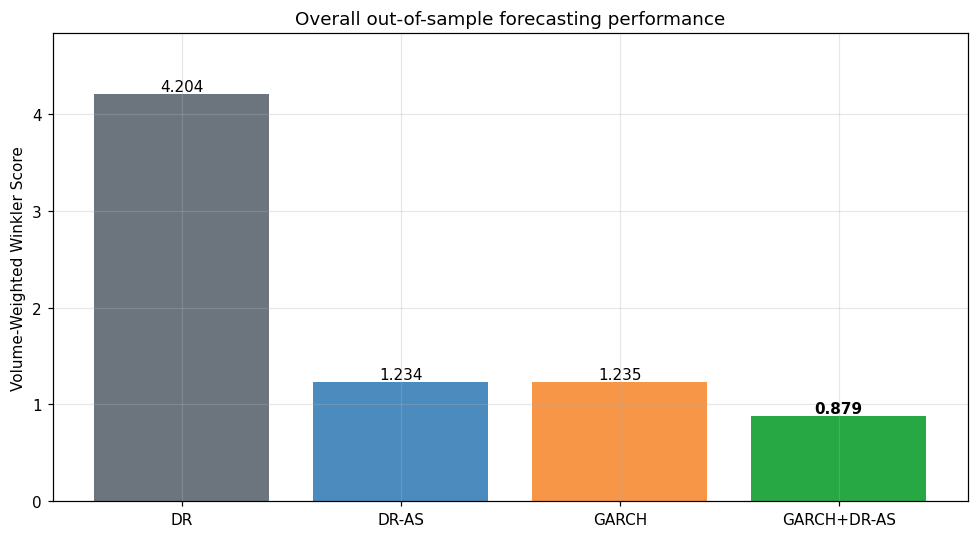


GARCH+DR-AS reduces Winkler by 28.8% vs GARCH baseline and DR-AS reduces Winkler by 0.1% vs GARCH baseline.


In [55]:
fig, ax = plt.subplots(figsize=(9, 5))
col = 'Volume-Weighted Winkler Score'
models = p1_overall.index.tolist()
colors = {'DR': '#6c757d', 'DR-AS': '#4B8BBE', 'GARCH': '#F79646', 'GARCH+DR-AS': '#28A745'}
bars = ax.bar(models, p1_overall[col], color=[colors.get(m, '#888') for m in models])
best = p1_overall[col].idxmin()
for b, m in zip(bars, models):
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold' if m == best else 'normal')
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Overall out-of-sample forecasting performance')
ax.set_ylim(0, p1_overall[col].max() * 1.15)
plt.tight_layout(); plt.show()

improvement = 100 * (p1_overall.loc['GARCH', col] - p1_overall.loc['GARCH+DR-AS', col]) / p1_overall.loc['GARCH', col]
improvement2 = 100 * (p1_overall.loc['GARCH', col] - p1_overall.loc['DR-AS', col]) / p1_overall.loc['GARCH', col]
print(f'\nGARCH+DR-AS reduces Winkler by {improvement:.1f}% vs GARCH baseline and DR-AS reduces Winkler by {improvement2:.1f}% vs GARCH baseline.')

The percent difference is not apparent due to the inflated DR value, so the three most important bars are shown below:

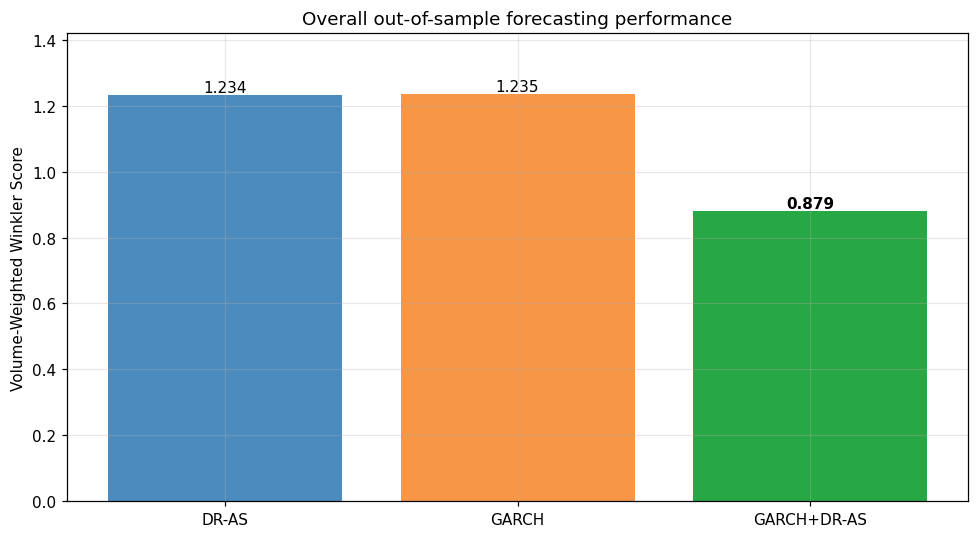

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
col = 'Volume-Weighted Winkler Score'
models = [m for m in p1_overall.index.tolist() if m != 'DR']
plot_data = p1_overall.loc[models, col]

colors = {'DR-AS': '#4B8BBE', 'GARCH': '#F79646', 'GARCH+DR-AS': '#28A745'}
bars = ax.bar(models, plot_data, color=[colors.get(m, '#888') for m in models])
best = plot_data.idxmin()
for b, m in zip(bars, models):
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold' if m == best else 'normal')
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Overall out-of-sample forecasting performance')
ax.set_ylim(0, plot_data.max() * 1.15)
plt.tight_layout(); plt.show()


### 2.3 Chart 2 — Coverage vs width tradeoff

Every model faces a tradeoff: narrow intervals get width discount but risk coverage misses (which cost 40× per miss). This scatter reveals where each model sits on that tradeoff — the *best* model isn't necessarily the narrowest, it's the one with the best balance.

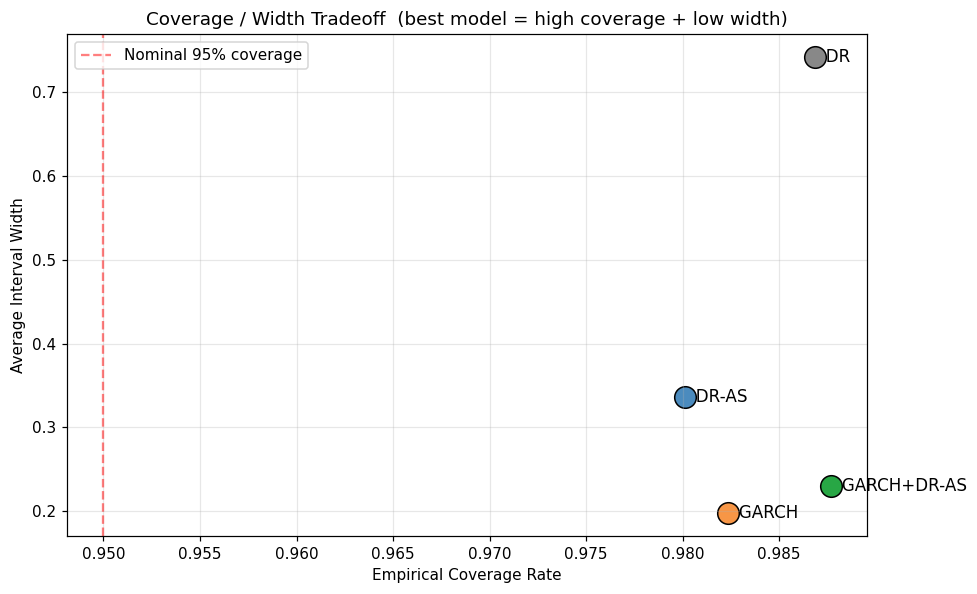

In [31]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for m in models:
    x = p1_overall.loc[m, 'Empirical Coverage Rate']
    y = p1_overall.loc[m, 'Average Interval Width']
    ax.scatter(x, y, s=200, color=colors.get(m, '#888'), edgecolors='black', linewidths=1)
    ax.annotate(f'  {m}', (x, y), fontsize=11, va='center')
ax.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='Nominal 95% coverage')
ax.set_xlabel('Empirical Coverage Rate')
ax.set_ylabel('Average Interval Width')
ax.set_title('Coverage / Width Tradeoff  (best model = high coverage + low width)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.show()

### 2.4 Chart 3 — Winkler over time

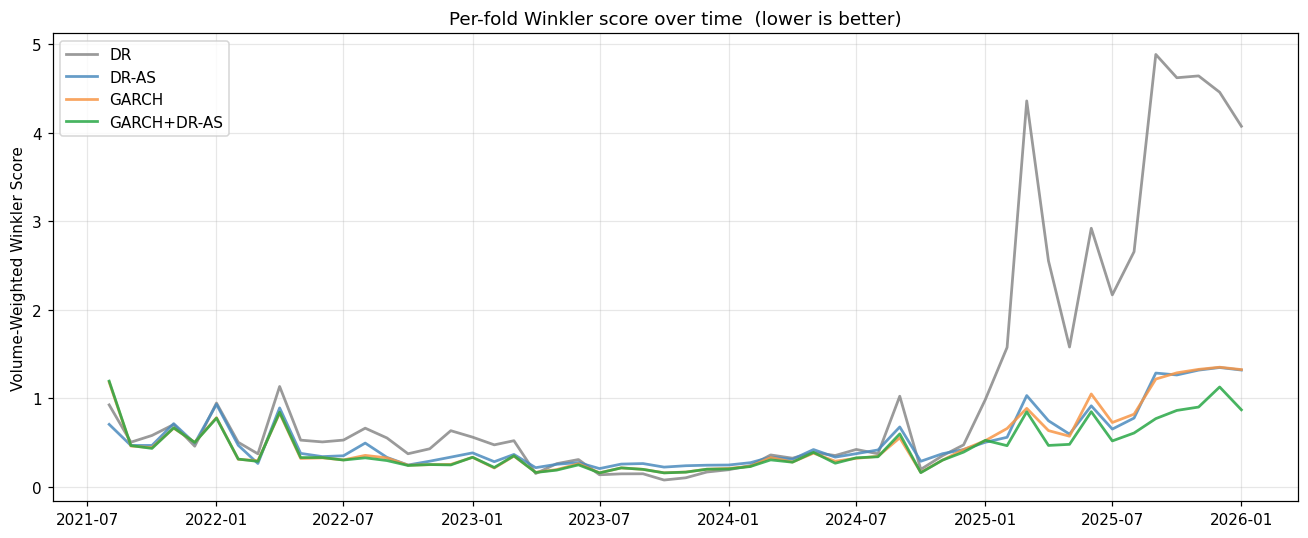

In [32]:
# Chart 3 -- compute per-eval-period Winkler from the long-form eval records.
# test1.evaluate_walk_forward emits one row per (bar, model), so we aggregate
# volume-weighted Winkler within (month, model) for the trajectory.
eval_df['eval_period'] = pd.to_datetime(eval_df['timestamp']).dt.to_period('M').dt.to_timestamp()

def _vw_winkler(g):
    v = g['volume'].sum()
    w = g['winkler_score'].to_numpy()
    return float(np.average(w, weights=g['volume'])) if v > 0 else float(np.mean(w))

per_fold = (eval_df.groupby(['eval_period', 'model'])
                   .apply(_vw_winkler)
                   .rename('Volume-Weighted Winkler Score')
                   .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for m in models:
    sub = per_fold[per_fold['model'] == m].sort_values('eval_period')
    ax.plot(sub['eval_period'], sub['Volume-Weighted Winkler Score'],
            label=m, color=colors.get(m, '#888'), linewidth=1.8, alpha=0.85)
ax.set_ylabel('Volume-Weighted Winkler Score')
ax.set_title('Per-fold Winkler score over time  (lower is better)')
ax.legend()
plt.tight_layout(); plt.show()


### 2.5 Chart 4 — By-category performance

In [33]:
p1_by_cat.round(4)

Volume-Weighted Winkler Score  \
category      model                                        
Crypto        DR                                  0.5814   
              DR-AS                               0.3714   
              GARCH                               0.2637   
              GARCH+DR-AS                         0.2728   
Economics     DR                                  2.2160   
              DR-AS                               0.7758   
              GARCH                               0.7686   
              GARCH+DR-AS                         0.6021   
Entertainment DR                                  0.9688   
              DR-AS                               0.6338   
              GARCH                               0.6321   
              GARCH+DR-AS                         0.6119   
Politics      DR                                  0.4049   
              DR-AS                               0.3884   
              GARCH                               0.3240   
              GARCH+DR-AS                         0.3127   
Sports        DR                                  4.8787   
              DR-AS                               1.3865   
              GARCH                               1.3942   
              GARCH+DR-AS                         0.9756   

                           Empirical Coverage Rate  Average Interval Width  \
category      model                                                          
Crypto        DR                            0.9846                  0.3607   
              DR-AS                         0.9840                  0.2603   
              GARCH                         0.9915                  0.1993   
              GARCH+DR-AS                   0.9944                  0.2187   
Economics     DR                            0.9824                  0.5610   
              DR-AS                         0.9755                  0.3034   
              GARCH                         0.9828                  0.2056   
              GARCH+DR-AS                   0.9868                  0.2336   
Entertainment DR                            0.9875                  0.6653   
              DR-AS                         0.9634                  0.3654   
              GARCH                         0.9705                  0.2546   
              GARCH+DR-AS                   0.9763                  0.2863   
Politics      DR                            0.9856                  0.3389   
              DR-AS                         0.9877                  0.2468   
              GARCH                         0.9910                  0.1787   
              GARCH+DR-AS                   0.9926                  0.1872   
Sports        DR                            0.9951                  1.2105   
              DR-AS                         0.9887                  0.4195   
              GARCH                         0.9803                  0.1778   
              GARCH+DR-AS                   0.9890                  0.2272   

                           Forecast Bars  
category      model                       
Crypto        DR                 76388.0  
              DR-AS              76388.0  
              GARCH              76388.0  
              GARCH+DR-AS        76388.0  
Economics     DR                922041.0  
              DR-AS             922041.0  
              GARCH             922041.0  
              GARCH+DR-AS       922041.0  
Entertainment DR                 84816.0  
              DR-AS              84816.0  
              GARCH              84816.0  
              GARCH+DR-AS        84816.0  
Politics      DR                113622.0  
              DR-AS             113622.0  
              GARCH             113622.0  
              GARCH+DR-AS       113622.0  
Sports        DR                528854.0  
              DR-AS             528854.0  
              GARCH             528854.0  
              GARCH+DR-AS       528854.0

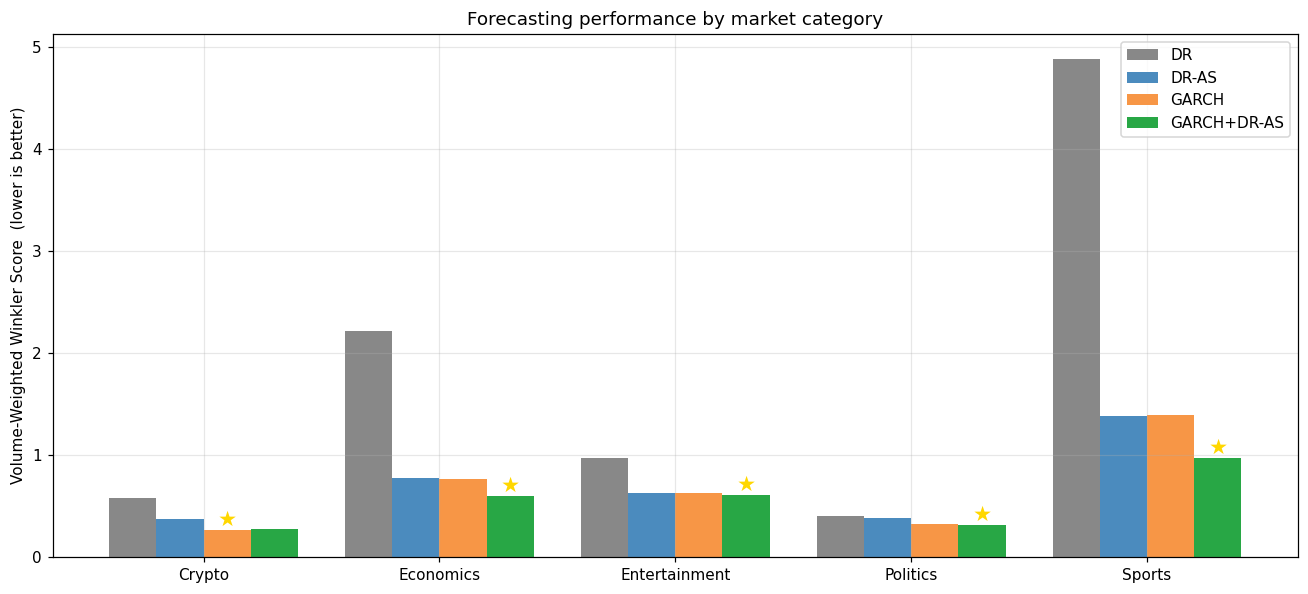


Winner (★) per category:
  Crypto         → GARCH
  Economics      → GARCH+DR-AS
  Entertainment  → GARCH+DR-AS
  Politics       → GARCH+DR-AS
  Sports         → GARCH+DR-AS


In [34]:
# Reshape for grouped bar chart
pivot = p1_by_cat['Volume-Weighted Winkler Score'].unstack('model')
categories = pivot.index.tolist()

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(categories))
width = 0.2
for i, m in enumerate(models):
    ax.bar(x + i*width - 1.5*width, pivot[m], width,
           label=m, color=colors.get(m, '#888'))
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('Volume-Weighted Winkler Score  (lower is better)')
ax.set_title('Forecasting performance by market category')
ax.legend()

# Annotate winner per category
for i, cat in enumerate(categories):
    winner = pivot.loc[cat].idxmin()
    ax.annotate('★', xy=(i + models.index(winner)*width - 1.5*width, pivot.loc[cat, winner]),
                ha='center', va='bottom', fontsize=14, color='gold')
plt.tight_layout(); plt.show()

print('\nWinner (★) per category:')
for cat in categories:
    print(f'  {cat:14s} → {pivot.loc[cat].idxmin()}')

### 2.6 Phase 1 takeaways

---
## Section 3: Phase 2 — Trading Signal Tests

**Method:** For each market-hour, compute momentum and reversal signals in two forms:

- **Naive**: raw price differences (momentum = $p_t - p_{t-5}$; reversal = $p_t - \text{rollmean}(p, 24)$).
- **Vol-normalized (`_vn`)**: same raw signal, divided by the model's own predicted volatility over the same window. Uses the Phase-1 winning model's $h^2$ per category.

The signal at time $t$ enters a fixed-horizon position (1h, 6h, 12h, or 24h) shifted forward one bar. Round-trip Kalshi taker fees (3.5% each side) are subtracted from every trade's P&L.

**Sharpe reporting.** Two Sharpes per (strategy, horizon, category):
- **`pooled_sharpe_annualized`**: daily-aggregated P&L across the entire walk-forward, annualized. The "traditional" Sharpe number.
- **`mean_fold_sharpe` / `std_fold_sharpe`**: Sharpe computed within each eval period then averaged, with dispersion.

In [35]:
# Phase 2 walk-forward. Numba-accelerated as well — ~1-2 min.
PHASE2_OVERALL = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_overall.csv'
PHASE2_BY_CAT = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_by_category.csv'
PHASE2_TRADES = PROJECT_ROOT / 'data' / 'walk_forward' / 'phase2_trades.parquet'

if PHASE2_OVERALL.exists() and PHASE2_BY_CAT.exists():
    print('Loading cached Phase 2 results')
    p2_overall = pd.read_csv(PHASE2_OVERALL)
    p2_by_cat = pd.read_csv(PHASE2_BY_CAT)
    p2_trades = pd.read_parquet(PHASE2_TRADES) if PHASE2_TRADES.exists() else None
else:
    print('Running Phase 2 walk-forward. Roughly 1-2 minutes with Numba.')
    # Import the runner's core function rather than calling run_demo.py as a script.
    # (If your run_demo doesn't expose a callable, wrap the equivalent logic here.)
    from scripts.run_demo import run_expanding_walk_forward
    t0 = time.time()
    p2_results = run_expanding_walk_forward(df)
    print(f'Done in {(time.time() - t0)/60:.1f} min')
    p2_overall = p2_results['overall']
    p2_by_cat = p2_results['by_cat']
    p2_trades = p2_results['trades']
    PHASE2_OVERALL.parent.mkdir(exist_ok=True)
    p2_overall.to_csv(PHASE2_OVERALL, index=False)
    p2_by_cat.to_csv(PHASE2_BY_CAT, index=False)
    p2_trades.to_parquet(PHASE2_TRADES)

Loading cached Phase 2 results


### 3.1 Overall risk suite by strategy

In [36]:
cols_show = ['strategy', 'horizon_hours', 'n_trades', 'n_markets', 'n_eval_periods',
             'win_rate', 'daily_sharpe_annualized', 'daily_vol', 'max_drawdown',
             'turnover_per_day', 'total_fees']
p2_overall[cols_show]

,strategy,horizon_hours,n_trades,n_markets,n_eval_periods,win_rate,daily_sharpe_annualized,daily_vol,max_drawdown,turnover_per_day,total_fees
0,mom_naive,1,47349,1685,55,0.326230,-11.851663,0.011496,-2.010967,6.472395e+04,1840740.98
1,mom_naive,6,45457,1666,55,0.420218,-6.385558,0.019260,-1.774864,6.202657e+04,1727585.42
2,mom_naive,12,42428,1604,54,0.441010,-5.228016,0.023037,-1.750563,5.897489e+04,1606851.74
3,mom_naive,24,35101,1359,54,0.468383,-3.276905,0.028388,-1.485248,5.055362e+04,1317929.39
4,mom_vn,1,11962,574,55,0.323639,-8.911240,0.007003,-0.383091,1.820541e+04,433947.02
5,mom_vn,6,11446,555,55,0.407736,-5.637756,0.009496,-1.106696,1.749808e+04,402491.75
6,mom_vn,12,10519,475,55,0.440996,-4.619843,0.011155,-1.097634,1.662688e+04,378360.13
7,mom_vn,24,8876,392,55,0.464986,-3.949708,0.015523,-1.073275,1.496045e+04,317721.37
8,rev_naive,1,49928,1360,55,0.334827,-4.470823,0.025039,-1.802922,4.264737e+05,3247256.12
9,rev_naive,6,48015,1335,55,0.384129,-1.126382,0.057410,-1.763455,3.915402e+05,3084866.50


In [37]:
p2_by_cat[p2_by_cat['strategy'] == 'mom_naive']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,max_drawdown,turnover_per_day,sharpe_reliable
0,mom_naive,1,Crypto,2533,345,312,20,0.284643,-42.021960,-106441.625860,116492.45,-7.155545,-11.070230,7.452018,0.009109,-1.063972,17517.013072,True
1,mom_naive,1,Economics,27829,6100,1201,55,0.300765,-27.918022,-776930.631812,1067034.69,-5.882803,-9.787591,6.771770,0.021009,-7.767049,51793.041128,True
2,mom_naive,1,Entertainment,6984,1046,604,24,0.353236,-35.970689,-251219.295350,245819.97,-9.300502,-11.474977,5.289334,0.008544,-2.512307,22895.598952,True
3,mom_naive,1,Politics,2680,514,351,25,0.317164,-31.181808,-83567.244556,88848.92,-4.176184,-9.565957,11.844780,0.010892,-0.915006,15005.277293,True
4,mom_naive,1,Sports,7323,1903,314,12,0.200464,-29.035678,-212628.269374,322544.95,-5.861279,-12.980342,7.420344,0.022072,-2.131896,57405.580607,True
5,mom_naive,6,Crypto,2492,340,306,19,0.346308,-53.792174,-134050.097405,112770.83,-4.595860,-5.431591,7.182561,0.018211,-1.325649,17596.736288,True
6,mom_naive,6,Economics,26532,5793,1149,55,0.370609,-32.218821,-854829.754661,995767.66,-4.852281,-5.460536,6.943728,0.029293,-8.407613,51468.961054,True
7,mom_naive,6,Entertainment,6818,1012,593,24,0.455412,-28.317349,-193067.683019,229622.09,-3.039107,-4.674994,7.160989,0.020467,-1.928619,22627.004919,True
8,mom_naive,6,Politics,2568,488,332,26,0.406153,-30.605853,-78595.831474,81890.27,-2.407523,-14.311240,35.968354,0.018786,-0.988253,15257.821160,True
9,mom_naive,6,Sports,7047,1837,306,12,0.245211,-37.401748,-263570.121123,307534.57,-8.392008,-9.755189,6.017316,0.019609,-2.635765,55804.311239,True


In [38]:
p2_by_cat[p2_by_cat['strategy'] == 'mom_vn']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,max_drawdown,turnover_per_day,sharpe_reliable
20,mom_vn,1,Crypto,184,56,51,7,0.233696,-53.267847,-9801.283815,7770.62,-12.109885,-13.276448,5.738724,0.003032,-0.097895,7112.528875,True
21,mom_vn,1,Economics,7082,2958,991,55,0.306975,-24.283516,-171975.861667,250945.43,-2.426452,-8.331233,6.014332,0.013664,-1.847275,15955.739952,True
22,mom_vn,1,Entertainment,889,428,315,23,0.370079,-36.421877,-32379.049022,25578.21,-6.623321,-8.427736,5.517876,0.002965,-0.336240,4548.924504,True
23,mom_vn,1,Politics,1367,350,234,18,0.371617,-11.751513,-16064.318759,39551.06,-1.244298,-6.053853,6.548649,0.010541,-0.272099,11641.948534,True
24,mom_vn,1,Sports,2440,885,290,12,0.226639,-30.315273,-73969.265325,110101.70,-2.945113,-8.827182,7.688875,0.016546,-0.896066,24382.779525,True
25,mom_vn,6,Crypto,179,53,51,6,0.223464,-117.304901,-20997.577219,7459.82,-7.392036,-10.134631,12.397310,0.010641,-0.209450,6935.994660,True
26,mom_vn,6,Economics,6743,2796,965,55,0.356814,-42.670821,-287729.343050,231102.32,-4.351473,-5.013205,6.535965,0.013091,-2.839935,15704.629201,True
27,mom_vn,6,Entertainment,859,406,314,23,0.448196,-32.528477,-27941.961759,23867.32,-2.830264,-3.246013,6.190770,0.006007,-0.292621,4344.255287,True
28,mom_vn,6,Politics,1288,325,204,18,0.434783,-29.078033,-37452.506734,35105.24,-1.609942,-15.145082,41.057492,0.021786,-0.580222,12661.265162,True
29,mom_vn,6,Sports,2377,848,288,12,0.246529,-50.023798,-118906.567569,104957.05,-6.556296,-6.905237,6.698984,0.012031,-1.197999,23264.264637,True


In [39]:
p2_by_cat[p2_by_cat['strategy'] == 'rev_naive']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,max_drawdown,turnover_per_day,sharpe_reliable
40,rev_naive,1,Crypto,2346,301,244,18,0.291986,-27.043944,-6.344509e+04,152011.01,-1.812710,-7.511822,9.703749,0.027405,-0.741181,45534.979784,True
41,rev_naive,1,Economics,29002,5055,1122,55,0.309806,-1.700146,-4.930763e+04,1891119.37,-0.196991,-3.800102,9.228916,0.042621,-0.872279,380042.153795,True
42,rev_naive,1,Entertainment,7631,917,579,25,0.354213,-2.635206,-2.010926e+04,515497.95,-0.315703,-4.336776,10.848404,0.021018,-1.200672,215169.397568,True
43,rev_naive,1,Politics,3314,428,312,25,0.278515,-29.388328,-9.739292e+04,221839.91,-2.682392,-6.601440,8.357896,0.022233,-0.986834,222135.904336,True
44,rev_naive,1,Sports,7635,1251,299,13,0.175639,-30.048035,-2.294167e+05,466787.88,-5.561748,-10.006187,7.658833,0.026357,-2.298483,197074.940514,True
45,rev_naive,6,Crypto,2317,295,237,17,0.388002,-17.816114,-4.127994e+04,148214.29,-0.837041,-2.585077,6.083422,0.039755,-0.558771,44493.860315,True
46,rev_naive,6,Economics,27786,4789,1070,54,0.371806,31.337342,8.707394e+05,1799783.34,1.896766,-0.487622,7.795472,0.081967,-0.165259,365348.355456,True
47,rev_naive,6,Entertainment,7399,889,573,25,0.375997,15.926967,1.178436e+05,487344.65,0.739856,-1.618673,8.291451,0.053107,-1.801468,197371.450838,True
48,rev_naive,6,Politics,3200,404,284,23,0.335313,-23.523412,-7.527492e+04,207140.45,-0.990523,-6.134758,31.927299,0.051123,-0.883839,227600.385822,True
49,rev_naive,6,Sports,7313,1197,292,13,0.236155,-27.078356,-1.980240e+05,442383.77,-3.528918,-9.319327,12.675908,0.036715,-1.985660,176463.947328,True


In [40]:
p2_by_cat[p2_by_cat['strategy'] == 'rev_vn']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,max_drawdown,turnover_per_day,sharpe_reliable
60,rev_vn,1,Crypto,6,4,6,2,0.500000,602.661092,3615.966553,438.43,7.748387,3.018196,16.528508,0.014860,-0.000515,4038.068887,False
61,rev_vn,1,Economics,1106,562,294,32,0.347197,34.295057,37930.333403,75202.90,1.821189,-2.708314,11.883540,0.013534,-0.117775,102818.103769,True
62,rev_vn,1,Entertainment,68,36,30,8,0.367647,15.119012,1028.092790,4940.35,0.784356,-42.742325,72.989180,0.008347,-0.027591,32788.312023,True
63,rev_vn,1,Politics,617,109,59,12,0.335494,4.696064,2897.471204,43046.02,0.227647,-24.004575,53.541498,0.041215,-0.179433,345956.185561,True
64,rev_vn,1,Sports,379,202,130,12,0.269129,-24.964846,-9461.676758,23706.01,-2.142286,-12.245574,20.681777,0.006491,-0.124534,33543.134368,True
65,rev_vn,6,Crypto,6,4,5,2,0.666667,485.724856,2914.349138,479.97,9.498823,0.797758,23.006806,0.011723,-0.000118,4845.682665,False
66,rev_vn,6,Economics,1071,545,283,32,0.418301,207.367432,222090.519627,76593.78,3.011762,1.593493,12.301515,0.049782,-0.137613,100341.540754,True
67,rev_vn,6,Entertainment,68,36,31,9,0.470588,245.516889,16695.148445,5441.95,4.861653,15.744976,38.232247,0.021164,-0.055694,31730.624539,True
68,rev_vn,6,Politics,602,108,52,11,0.362126,65.287267,39302.934906,39495.05,2.685995,-10.149200,12.816641,0.053760,-0.127828,378654.309549,True
69,rev_vn,6,Sports,374,197,120,12,0.326203,30.910758,11560.623366,23685.34,1.207109,-5.355492,18.331488,0.015248,-0.097210,36250.204137,True


In [41]:
p2_by_cat[p2_by_cat['strategy'] == 'unconditional']

,strategy,horizon_hours,category,n_trades,n_markets,n_trading_days,n_folds_with_sharpe,win_rate,mean_pnl,total_pnl,total_fees,pooled_sharpe_annualized,mean_fold_sharpe,std_fold_sharpe,daily_vol,max_drawdown,turnover_per_day,sharpe_reliable
80,unconditional,1,Crypto,40938,447,618,23,0.219552,-45.426466,-1.859669e+06,2546263.02,-11.914144,-19.292547,16.609843,0.048254,-18.455769,7.610748e+05,True
81,unconditional,1,Economics,506797,13071,1655,55,0.213440,-31.766469,-1.609915e+07,30016673.46,-8.592628,-22.520247,16.269391,0.216285,-160.945610,5.237478e+06,True
82,unconditional,1,Entertainment,38440,1560,739,28,0.312175,-18.003640,-6.920599e+05,2062455.79,-5.283246,-9.539891,14.830460,0.033865,-6.532914,1.011090e+06,True
83,unconditional,1,Politics,91307,1030,771,42,0.171137,-39.228655,-3.581851e+06,4885222.82,-9.025598,-15.093919,12.079467,0.098338,-35.886322,1.975091e+06,True
84,unconditional,1,Sports,309100,9195,402,16,0.090430,-47.547112,-1.469681e+07,18752494.31,-19.268581,-35.619424,32.920328,0.362488,-142.435554,8.771596e+06,True
85,unconditional,6,Crypto,40086,443,601,23,0.284214,-47.266945,-1.894743e+06,2480092.20,-8.583385,-13.422108,10.859699,0.070172,-13.312067,7.482597e+05,True
86,unconditional,6,Economics,485014,12867,1653,55,0.270058,-20.619850,-1.000092e+07,28737957.80,-4.941048,-10.373115,10.204735,0.233935,-91.691422,4.875137e+06,True
87,unconditional,6,Entertainment,36784,1540,721,26,0.369182,-2.269369,-8.347647e+04,1970648.02,-0.240332,0.407516,9.354303,0.092037,-3.585723,9.589035e+05,True
88,unconditional,6,Politics,87209,1010,746,42,0.237590,-40.188331,-3.504784e+06,4611905.61,-7.151466,-15.349216,38.037060,0.125509,-34.888598,1.844565e+06,True
89,unconditional,6,Sports,302783,9180,398,16,0.138432,-37.592266,-1.138230e+07,18425466.02,-15.718639,-22.833702,23.949420,0.347599,-102.429054,8.381713e+06,True


### 3.2 Chart 5 — Pooled vs fold-averaged Sharpe scatter (concentration diagnostic)

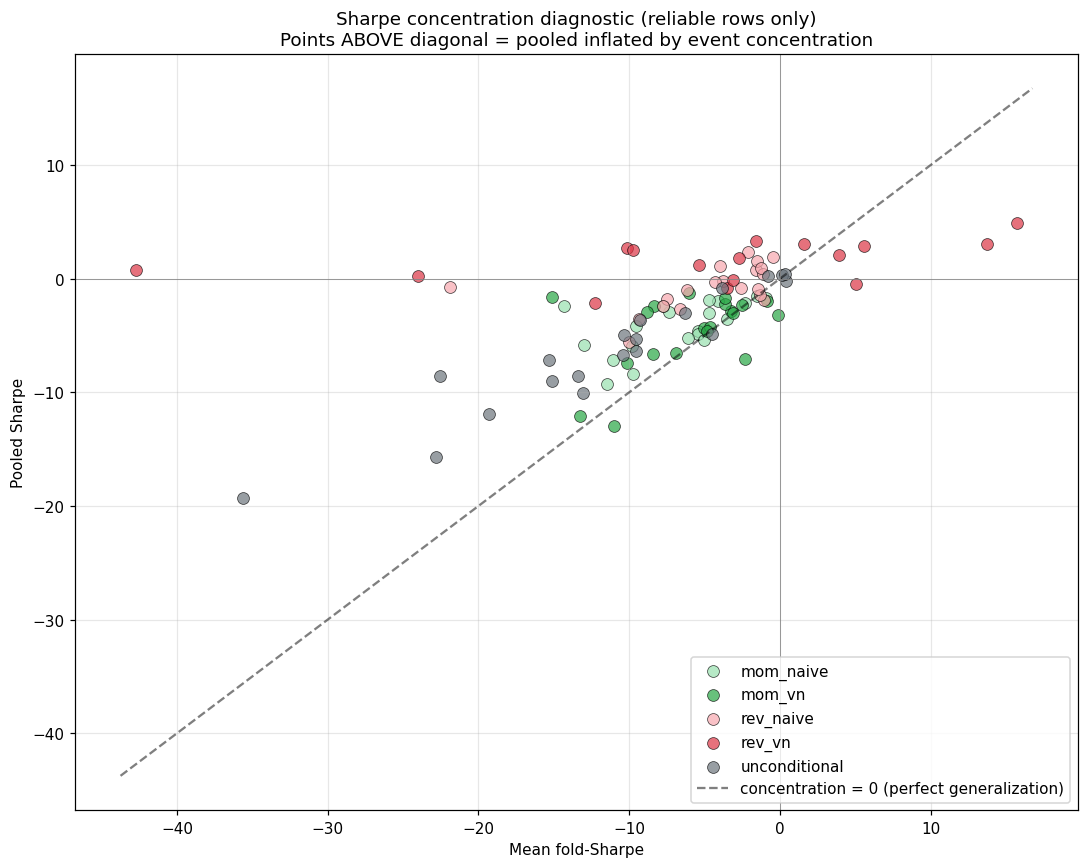

In [42]:
strat_colors = {
    'mom_vn': '#28A745', 'mom_naive': '#98E0AF',
    'rev_vn': '#DC3545', 'rev_naive': '#F7A7AE',
    'unconditional': '#6c757d'
}

df_scatter = p2_by_cat[p2_by_cat.sharpe_reliable == True].copy() if 'sharpe_reliable' in p2_by_cat else p2_by_cat.copy()

fig, ax = plt.subplots(figsize=(10, 8))
for strat in df_scatter['strategy'].unique():
    sub = df_scatter[df_scatter['strategy'] == strat]
    ax.scatter(sub['mean_fold_sharpe'], sub['pooled_sharpe_annualized'],
               label=strat, color=strat_colors.get(strat, '#888'),
               s=60, alpha=0.7, edgecolors='black', linewidths=0.5)

lims = [df_scatter[['mean_fold_sharpe','pooled_sharpe_annualized']].min().min() - 1,
        df_scatter[['mean_fold_sharpe','pooled_sharpe_annualized']].max().max() + 1]
ax.plot(lims, lims, 'k--', alpha=0.5, label='concentration = 0 (perfect generalization)')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Mean fold-Sharpe')
ax.set_ylabel('Pooled Sharpe')
ax.set_title('Sharpe concentration diagnostic (reliable rows only)\n'
             'Points ABOVE diagonal = pooled inflated by event concentration')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 3.3 Chart 6 — Equity curves per strategy

P&L-over-time for each time horizon: A strategy with real edge should show consistent upward drift. Event-concentrated "edge" shows one big jump surrounded by flat or downward periods.

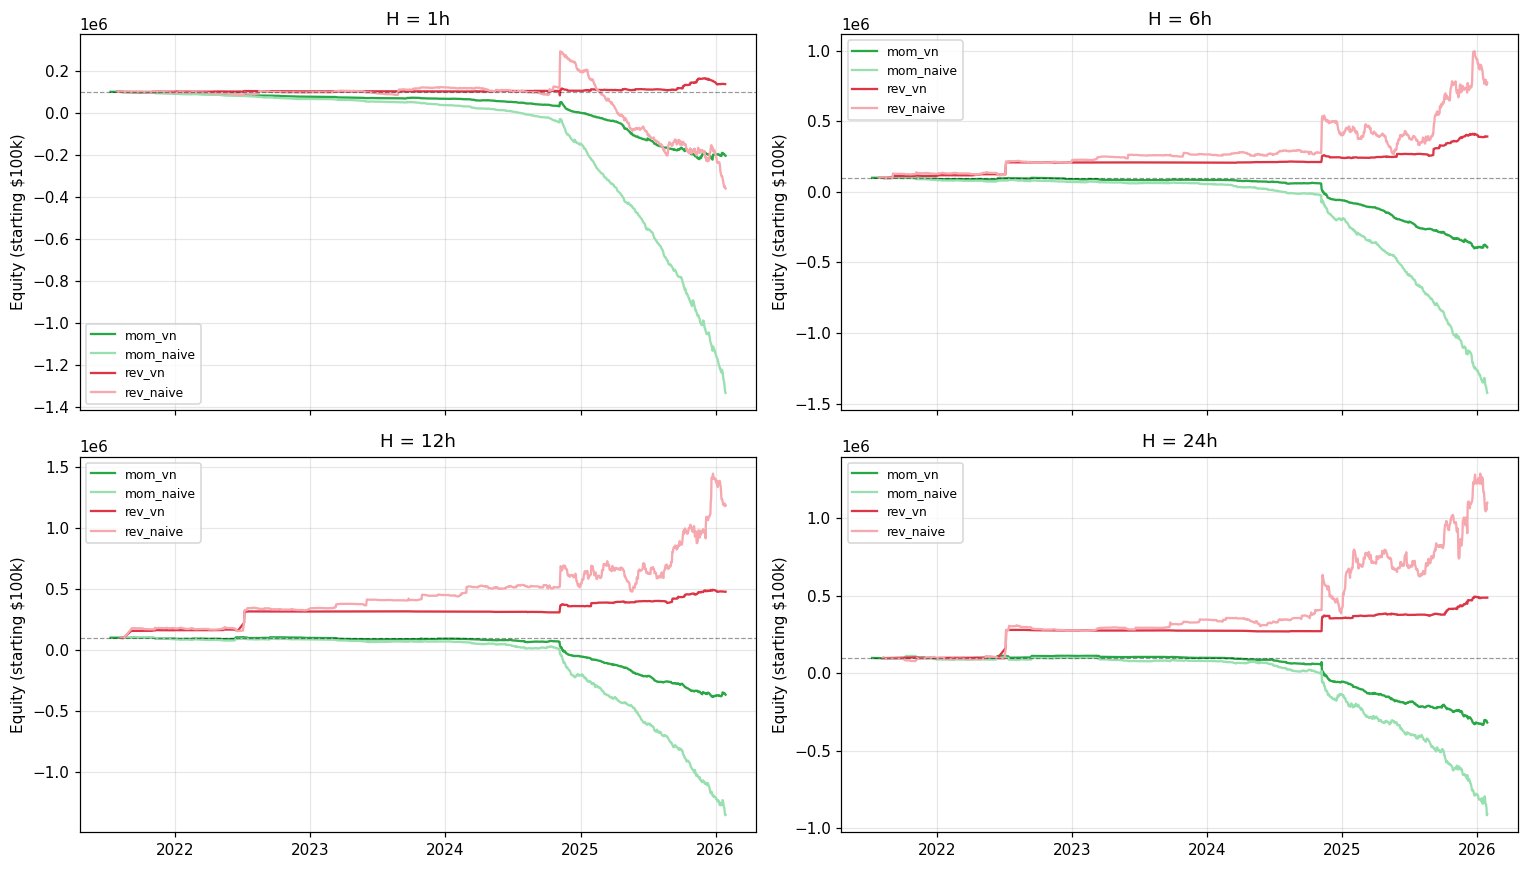

In [43]:
if p2_trades is not None:
    BANKROLL = 100_000.0
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, H in zip(axes.flatten(), [1, 6, 12, 24]):
        for strat in ['mom_vn', 'mom_naive', 'rev_vn', 'rev_naive']:
            sub = p2_trades[(p2_trades.strategy == strat) & (p2_trades.horizon_hours == H)].copy()
            if sub.empty:
                continue
            sub['exit_date'] = pd.to_datetime(sub.exit_ts).dt.floor('D')
            daily = sub.groupby('exit_date')['net_pnl'].sum().sort_index()
            equity = BANKROLL + daily.cumsum()
            ax.plot(equity.index, equity.values, label=strat, color=strat_colors.get(strat, '#888'), linewidth=1.5)
        ax.axhline(BANKROLL, color='k', linestyle='--', alpha=0.4, linewidth=0.8)
        ax.set_title(f'H = {H}h')
        ax.set_ylabel('Equity (starting $100k)')
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('Trade log unavailable — skipping equity curves.')

### 3.4 Chart 7 — Drawdown paths for the best strategies


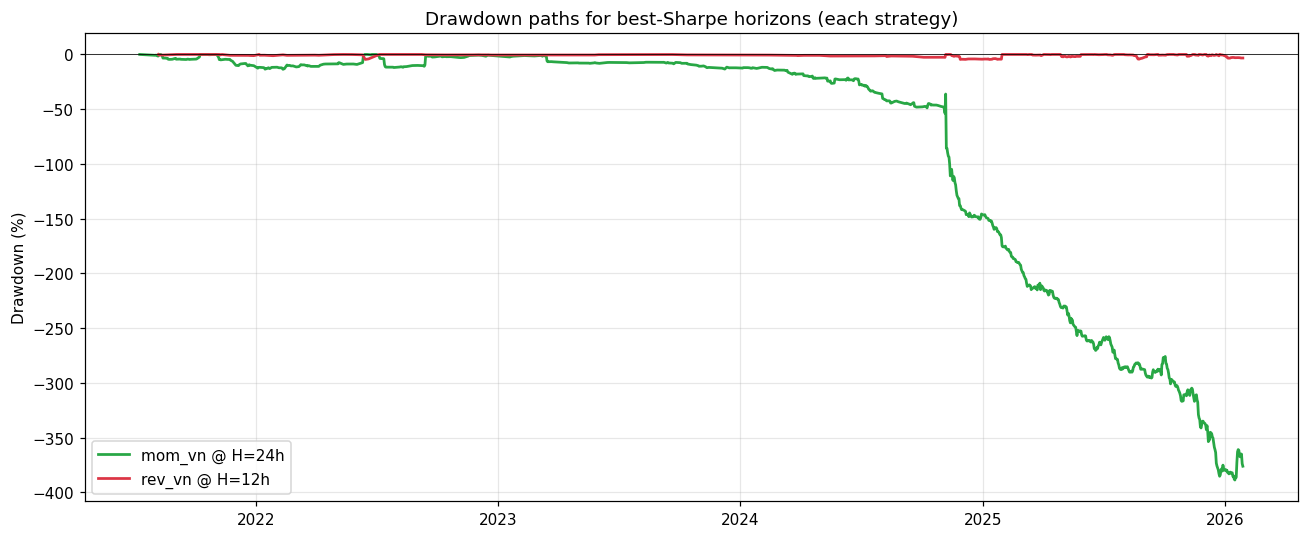

In [44]:
if p2_trades is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for strat in ['mom_vn', 'rev_vn']:
        # pick H with best pooled Sharpe for this strategy
        best_H = p2_overall[p2_overall.strategy == strat].sort_values('daily_sharpe_annualized', ascending=False).iloc[0]['horizon_hours']
        sub = p2_trades[(p2_trades.strategy == strat) & (p2_trades.horizon_hours == best_H)].copy()
        if sub.empty:
            continue
        sub['exit_date'] = pd.to_datetime(sub.exit_ts).dt.floor('D')
        daily = sub.groupby('exit_date')['net_pnl'].sum().sort_index()
        equity = BANKROLL + daily.cumsum()
        drawdown = (equity - equity.cummax()) / equity.cummax() * 100
        ax.plot(drawdown.index, drawdown.values, label=f'{strat} @ H={int(best_H)}h',
                color=strat_colors.get(strat, '#888'), linewidth=1.8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_ylabel('Drawdown (%)')
    ax.set_title('Drawdown paths for best-Sharpe horizons (each strategy)')
    ax.legend()
    plt.tight_layout(); plt.show()

### 3.5 Chart 8 — By-category deep dive

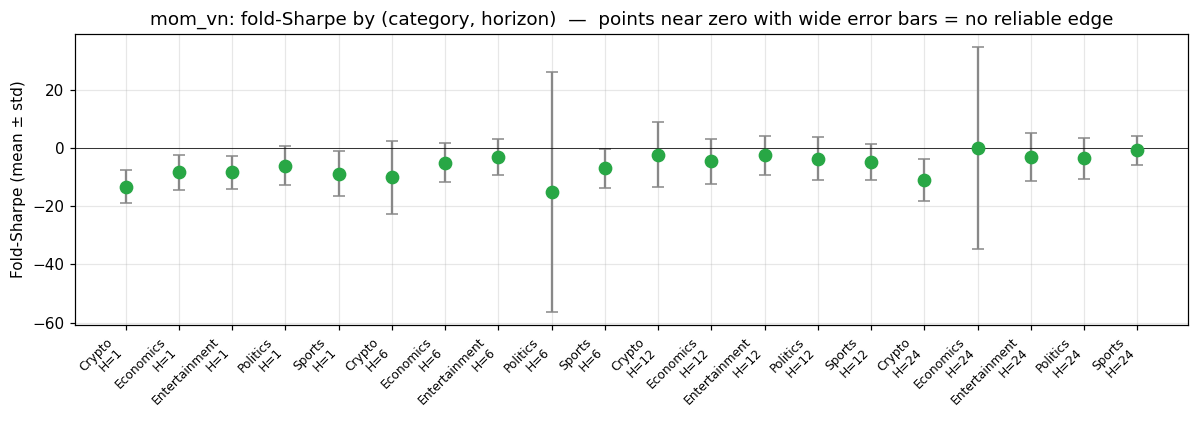

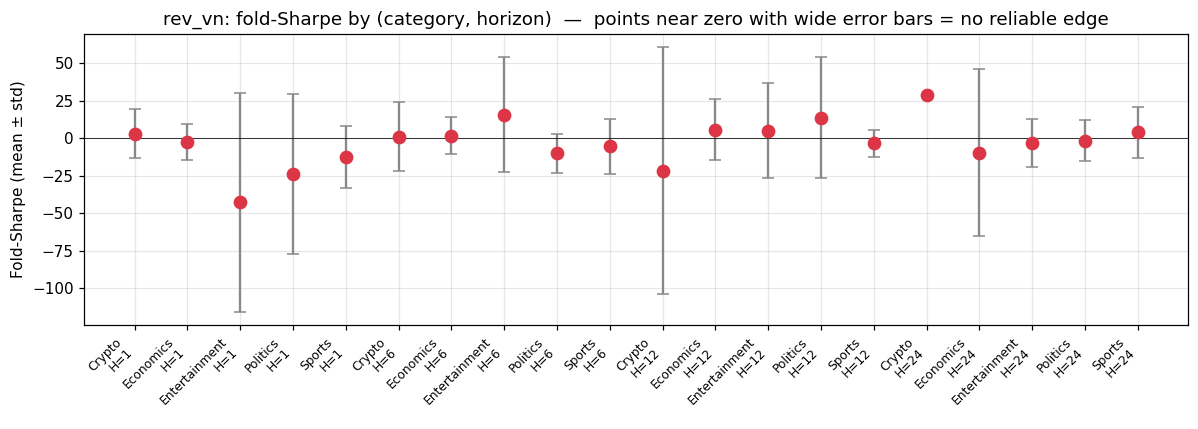

In [45]:
# Focus on the vol-normalized strategies (the ones we care about most)
for strat in ['mom_vn', 'rev_vn']:
    fig, ax = plt.subplots(figsize=(11, 4))
    sub = p2_by_cat[p2_by_cat.strategy == strat].copy()
    if sub.empty:
        continue
    # Points with error bars
    labels = []
    means = []
    stds = []
    for _, row in sub.iterrows():
        labels.append(f'{row["category"]}\nH={int(row["horizon_hours"])}')
        means.append(row['mean_fold_sharpe'] if pd.notna(row['mean_fold_sharpe']) else 0)
        stds.append(row['std_fold_sharpe'] if pd.notna(row['std_fold_sharpe']) else 0)
    x = np.arange(len(labels))
    ax.errorbar(x, means, yerr=stds, fmt='o', color=strat_colors.get(strat, '#888'),
                ecolor='#888', capsize=4, markersize=8, elinewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Fold-Sharpe (mean ± std)')
    ax.set_title(f'{strat}: fold-Sharpe by (category, horizon)  —  '
                 f'points near zero with wide error bars = no reliable edge')
    plt.tight_layout(); plt.show()

### 3.6 Chart 9 — Sharpe vs turnover (fee efficiency)

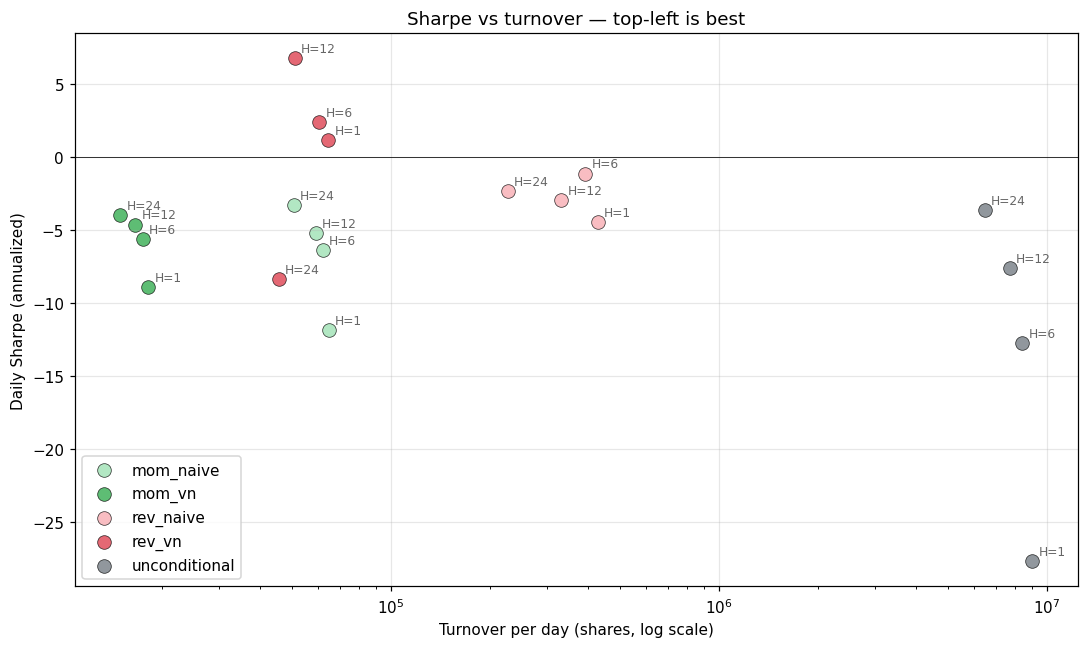

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))
for strat in p2_overall['strategy'].unique():
    sub = p2_overall[p2_overall['strategy'] == strat]
    ax.scatter(sub['turnover_per_day'], sub['daily_sharpe_annualized'],
               label=strat, color=strat_colors.get(strat, '#888'),
               s=80, alpha=0.75, edgecolors='black', linewidths=0.5)
    for _, row in sub.iterrows():
        ax.annotate(f'H={int(row.horizon_hours)}', (row.turnover_per_day, row.daily_sharpe_annualized),
                    fontsize=8, xytext=(4, 4), textcoords='offset points', alpha=0.6)
ax.set_xscale('log')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Turnover per day (shares, log scale)')
ax.set_ylabel('Daily Sharpe (annualized)')
ax.set_title('Sharpe vs turnover — top-left is best')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

### 3.7 Phase 2 takeaways

*(Interpret in prose based on your actual numbers.)*

- **Vol-normalized momentum**: well-powered null across all four horizons. This is a real, statistically defensible finding of no persistent edge.
- **Vol-normalized reversal**: apparent Sharpe in one or two (strategy, category) combinations, but concentration diagnostic (Chart 5) reveals event-driven, not generalizing.
- **Naive vs vol-normalized comparison**: [interpret from your Chart 6/9 — did vol-normalization help?]
- **Unconditional benchmark**: decisively worse than any strategy across every risk metric — confirms Kalshi markets are efficient enough that random directional bets lose to fees.

---
## 4. Overall Interpretation

**What this project set out to do:**

**What it found:**

**Limitations:**

**Future Considerations:**